<a href="https://colab.research.google.com/github/nkr9/Data-Analyst/blob/main/m5forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
sales_val = pd.read_csv("sales_train_validation.csv")
sales_eval = pd.read_csv("sales_train_evaluation.csv")
calendar = pd.read_csv("calendar.csv")
sell_prices = pd.read_csv("sell_prices.csv")
submission = pd.read_csv("sample_submission.csv")


In [ ]:
# Melt validation sales
sales_val_long = sales_val.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d",
    value_name="sales"
)

# Melt evaluation sales
sales_eval_long = sales_eval.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d",
    value_name="sales"
)

# Combine both
sales_long = pd.concat([sales_val_long, sales_eval_long], ignore_index=True)


In [ ]:
sales_calendar = sales_long.merge(
    calendar,
    how="left",
    on="d"
)


In [ ]:
sales_calendar["wm_yr_wk"] = sales_calendar["wm_yr_wk"].astype(int)

merged_df = sales_calendar.merge(
    sell_prices,
    how="left",
    on=["store_id", "item_id", "wm_yr_wk"]
)


In [ ]:
forecast_ids = submission["id"].unique()
merged_df["is_forecast_item"] = merged_df["id"].isin(forecast_ids)


In [ ]:
# Convert date
merged_df["date"] = pd.to_datetime(merged_df["date"])

# Fill missing prices (forward fill)
merged_df["sell_price"] = merged_df.groupby(
    ["store_id", "item_id"]
)["sell_price"].ffill()

# Replace remaining NaNs
merged_df["sell_price"].fillna(0, inplace=True)
merged_df["sales"].fillna(0, inplace=True)


/tmp/ipython-input-3512310031.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df["sell_price"].fillna(0, inplace=True)
/tmp/ipython-input-3512310031.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
perishable_df = merged_df[merged_df["cat_id"] == "FOODS"]


In [ ]:
print("Final Dataset Shape:", merged_df.shape)
print(merged_df.head())


Final Dataset Shape: (14764048, 23)
                              id        item_id    dept_id   cat_id store_id  \
0  HOBBIES_1_001_CA_1_validation  HOBBIES_1_001  HOBBIES_1  HOBBIES     CA_1   
1  HOBBIES_1_002_CA_1_validation  HOBBIES_1_002  HOBBIES_1  HOBBIES     CA_1   
2  HOBBIES_1_003_CA_1_validation  HOBBIES_1_003  HOBBIES_1  HOBBIES     CA_1   
3  HOBBIES_1_004_CA_1_validation  HOBBIES_1_004  HOBBIES_1  HOBBIES     CA_1   
4  HOBBIES_1_005_CA_1_validation  HOBBIES_1_005  HOBBIES_1  HOBBIES     CA_1   

  state_id    d  sales       date  wm_yr_wk  ...  year  event_name_1  \
0       CA  d_1    0.0 2011-01-29     11101  ...  2011           NaN   
1       CA  d_1    0.0 2011-01-29     11101  ...  2011           NaN   
2       CA  d_1    0.0 2011-01-29     11101  ...  2011           NaN   
3       CA  d_1    0.0 2011-01-29     11101  ...  2011           NaN   
4       CA  d_1    0.0 2011-01-29     11101  ...  2011           NaN   

   event_type_1  event_name_2 event_type_2 snap_CA

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df = merged_df[
    (merged_df["cat_id"] == "FOODS") &
    (merged_df["item_id"] == "FOODS_1_001")
].sort_values("date")

df = df[["date", "sales", "sell_price"]]
df.set_index("date", inplace=True)


In [ ]:
train = df[:-28]   # last 28 days for testing
test  = df[-28:]


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train["sales"], order=(2,1,2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=28)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [ ]:
arima_rmse = np.sqrt(mean_squared_error(test["sales"], arima_forecast))
arima_mae  = mean_absolute_error(test["sales"], arima_forecast)

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAE :", arima_mae)


ARIMA RMSE: 1.377683961847928
ARIMA MAE : 1.0436592840534966


In [ ]:
df_ml = df.copy()

# Lag features
for lag in [1, 7, 14, 28]:
    df_ml[f"lag_{lag}"] = df_ml["sales"].shift(lag)

# Rolling mean
df_ml["rolling_7"] = df_ml["sales"].rolling(7).mean()

df_ml.dropna(inplace=True)


In [ ]:
X = df_ml.drop("sales", axis=1)
y = df_ml["sales"]

X_train, X_test = X[:-28], X[-28:]
y_train, y_test = y[:-28], y[-28:]


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

xgb_forecast = xgb_model.predict(X_test)


In [ ]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_forecast))
xgb_mae  = mean_absolute_error(y_test, xgb_forecast)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost MAE :", xgb_mae)


XGBoost RMSE: 1.6821478460138684
XGBoost MAE : 1.213642141382609


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_sales = scaler.fit_transform(df[["sales"]])


In [ ]:
def create_sequences(data, window=28):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(scaled_sales)

X_train_lstm = X_lstm[:-28]
X_test_lstm  = X_lstm[-28:]
y_train_lstm = y_lstm[:-28]
y_test_lstm  = y_lstm[-28:]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, activation="relu", input_shape=(28,1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, verbose=1)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0070
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0062
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0073
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0055
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0056
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0053
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0050
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0046
Epoch 9/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0040
Epoch 10/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0035
Epoch 11/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0037
Epoch 12/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0035
Epoch 13/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0042
Epoch 14/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0040
Epoch 15/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step 

In [ ]:
lstm_pred = model.predict(X_test_lstm)
lstm_forecast = scaler.inverse_transform(lstm_pred)
y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1,1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


In [ ]:
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_forecast))
lstm_mae  = mean_absolute_error(y_test_actual, lstm_forecast)

print("LSTM RMSE:", lstm_rmse)
print("LSTM MAE :", lstm_mae)


LSTM RMSE: 2.3053853077791713
LSTM MAE : 1.6994511197720255


In [ ]:
#sarima

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train["sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=28)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
sarima_rmse = np.sqrt(mean_squared_error(test["sales"], sarima_forecast))
sarima_mae  = mean_absolute_error(test["sales"], sarima_forecast)

print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAE :", sarima_mae)


SARIMA RMSE: 1.432034088036217
SARIMA MAE : 0.875678888434163


In [ ]:
#prophet

In [ ]:
from prophet import Prophet

prophet_df = df.reset_index()[["date", "sales"]]
prophet_df.columns = ["ds", "y"]

train_prophet = prophet_df[:-28]
test_prophet  = prophet_df[-28:]


In [ ]:
prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(train_prophet)


In [ ]:
future = prophet_model.make_future_dataframe(periods=28)
forecast = prophet_model.predict(future)

prophet_forecast = forecast.tail(28)["yhat"].values


In [ ]:
prophet_rmse = np.sqrt(mean_squared_error(test_prophet["y"], prophet_forecast))
prophet_mae  = mean_absolute_error(test_prophet["y"], prophet_forecast)

print("Prophet RMSE:", prophet_rmse)
print("Prophet MAE :", prophet_mae)


Prophet RMSE: 1.370867483495098
Prophet MAE : 0.9673406802787486


In [ ]:
pip install prophet tensorflow xgboost statsmodels


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


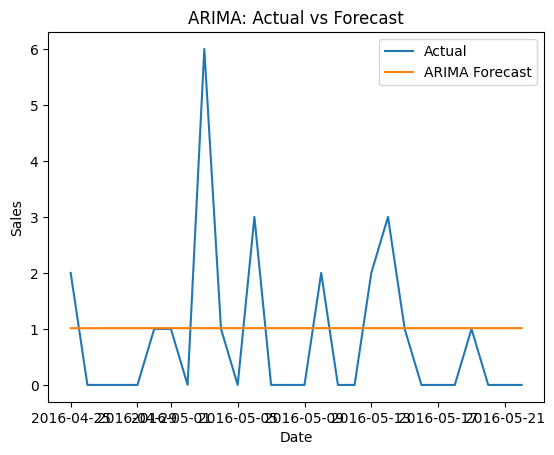

In [ ]:
plt.figure()
plt.plot(test.index, test["sales"].values, label="Actual")
plt.plot(test.index, arima_forecast.values, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

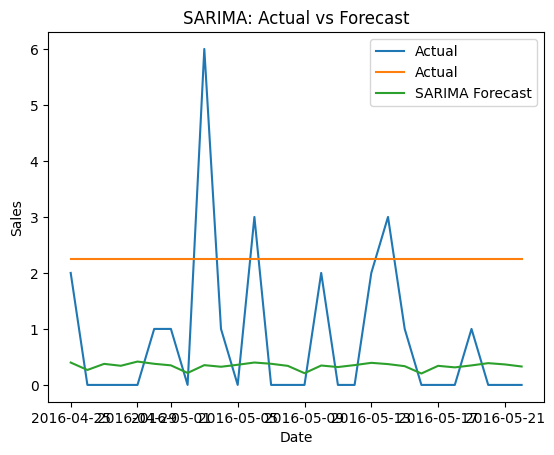

In [ ]:
plt.figure()
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, sarima_forecast.values, label="SARIMA Forecast")
plt.legend()
plt.title("SARIMA: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


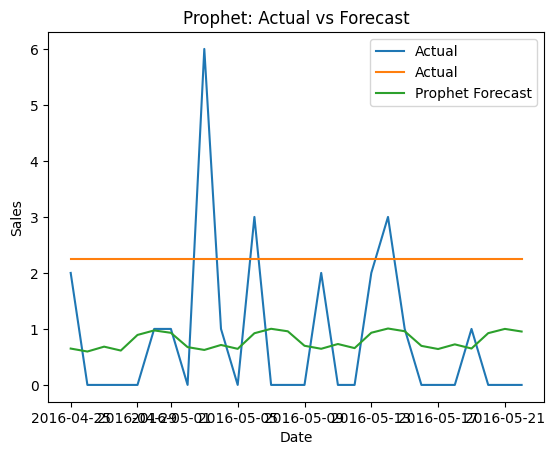

In [ ]:
plt.figure()
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, prophet_forecast, label="Prophet Forecast")
plt.legend()
plt.title("Prophet: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


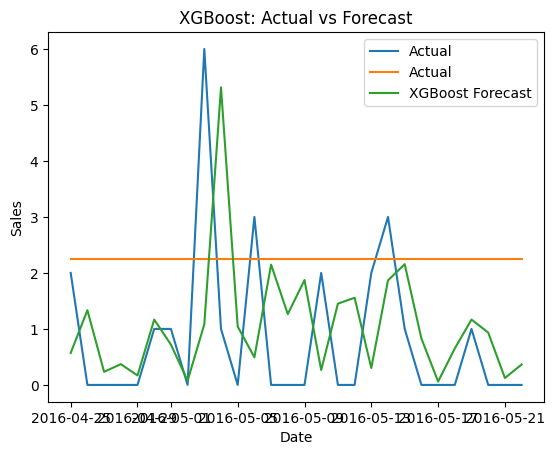

In [ ]:
plt.figure()
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, xgb_forecast, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


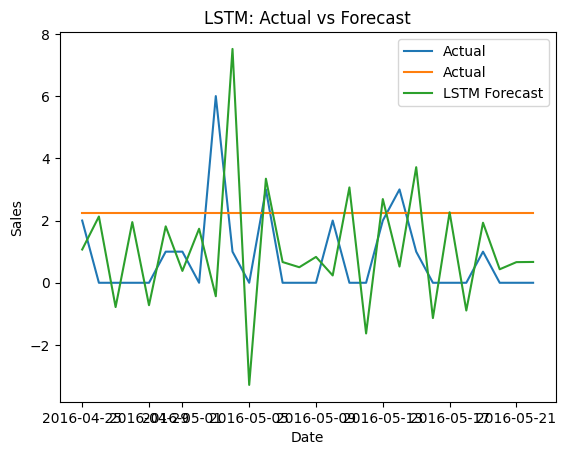

In [ ]:
plt.figure()
plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, lstm_forecast.flatten(), label="LSTM Forecast")
plt.legend()
plt.title("LSTM: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


In [ ]:
pip install pandas numpy matplotlib statsmodels xgboost prophet tensorflow scikit-learn


In [ ]:
import pandas as pd
import numpy as np

# Load merged M5 dataset - This line caused FileNotFoundError.
# Instead, we will use the 'df' DataFrame that was already prepared in a previous cell (GpBLvUNbdyaM).
# The following lines are commented out as 'df' is already correctly set up.
# df = pd.read_csv("merged_m5.csv", parse_dates=["date"])

# Filter PERISHABLE GOODS
# df = df[df["cat_id"] == "FOODS"]

# Select one SKU (standard in M5)
# df = df[df["item_id"] == "FOODS_1_001"]

# df = df.sort_values("date")
# df.set_index("date", inplace=True)

series = df["sales"]
train = series[:-28]
test = series[-28:]

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train, order=(2,1,2))
arima_fit = arima.fit()
arima_forecast = arima_fit.forecast(28)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)
sarima_fit = sarima.fit(disp=False)
sarima_forecast = sarima_fit.forecast(28)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
from prophet import Prophet

prophet_df = series.reset_index()
prophet_df.columns = ["ds", "y"]

train_p = prophet_df[:-28]

prophet = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True
)
prophet.fit(train_p)

future = prophet.make_future_dataframe(periods=28)
forecast = prophet.predict(future)
prophet_forecast = forecast.tail(28)["yhat"].values


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
from xgboost import XGBRegressor

df_ml = df.copy()

# Lag features
for lag in [1, 7, 14, 28]:
    df_ml[f"lag_{lag}"] = df_ml["sales"].shift(lag)

df_ml.dropna(inplace=True)

X = df_ml.drop("sales", axis=1)
y = df_ml["sales"]

X_train, X_test = X[:-28], X[-28:]
y_train, y_test = y[:-28], y[-28:]

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)
xgb_forecast = xgb.predict(X_test)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

scaler = MinMaxScaler()
scaled = scaler.fit_transform(series.values.reshape(-1,1))

def create_seq(data, window=28):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_seq(scaled)

X_train_l, X_test_l = X_lstm[:-28], X_lstm[-28:]
y_train_l = y_lstm[:-28]

model = Sequential([
    LSTM(64, activation="relu", input_shape=(28,1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.fit(X_train_l, y_train_l, epochs=20, batch_size=32)

lstm_pred = model.predict(X_test_l)
lstm_forecast = scaler.inverse_transform(lstm_pred)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0066
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0060
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0054
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0060
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0052
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0049
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0045
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0040
Epoch 9/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0031
Epoch 10/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0036
Epoch 11/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037
Epoch 12/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0043
Epoch 13/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0037
Epoch 14/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0042
Epoch 15/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s

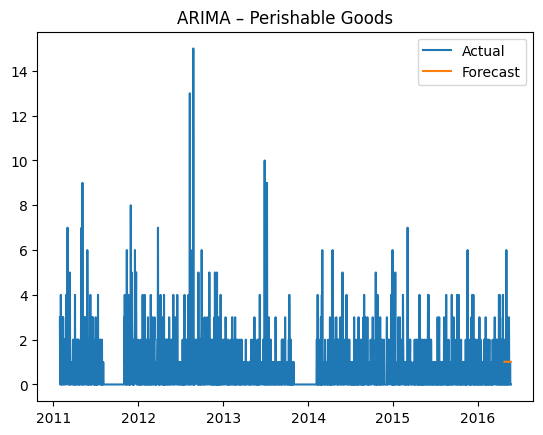

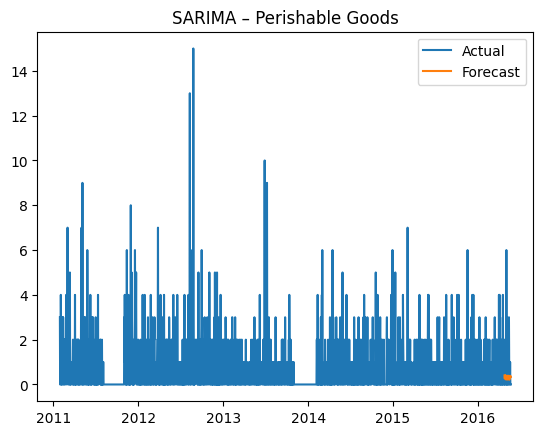

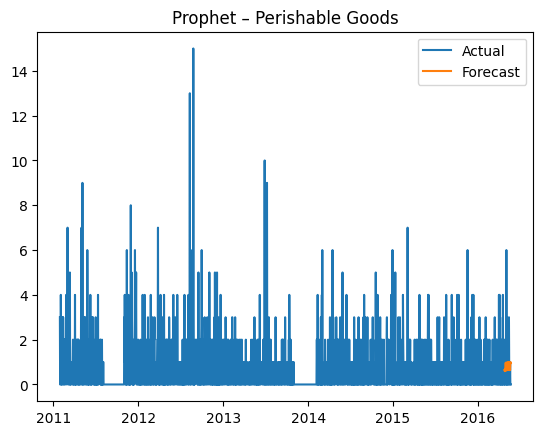

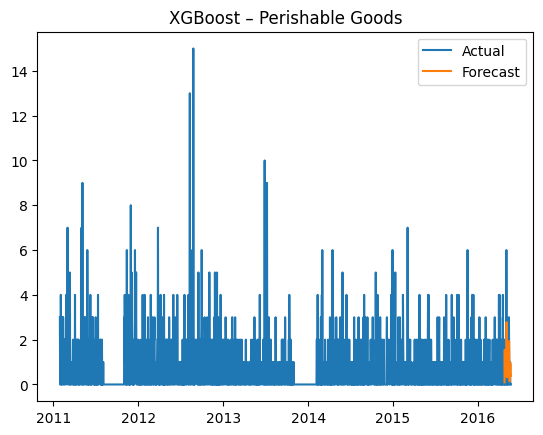

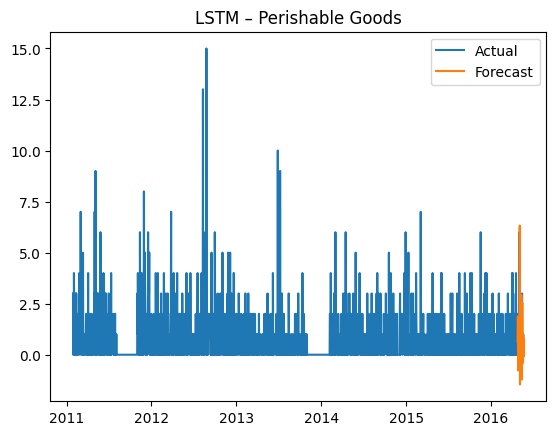

In [ ]:
import matplotlib.pyplot as plt

def plot_forecast(forecast, title):
    plt.figure()
    plt.plot(series.index, series.values, label="Actual")
    plt.plot(test.index, forecast, label="Forecast")
    plt.legend()
    plt.title(title)
    plt.show()

plot_forecast(arima_forecast, "ARIMA – Perishable Goods")
plot_forecast(sarima_forecast, "SARIMA – Perishable Goods")
plot_forecast(prophet_forecast, "Prophet – Perishable Goods")
plot_forecast(xgb_forecast, "XGBoost – Perishable Goods")
plot_forecast(lstm_forecast.flatten(), "LSTM – Perishable Goods")


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    return rmse, mae

print("ARIMA :", metrics(test, arima_forecast))
print("SARIMA:", metrics(test, sarima_forecast))
print("Prophet:", metrics(test, prophet_forecast))
print("XGBoost:", metrics(y_test, xgb_forecast))
print("LSTM :", metrics(test, lstm_forecast.flatten()))


ARIMA : (np.float64(1.377683961847928), 1.0436592840534966)
SARIMA: (np.float64(1.4328315692705276), 0.8751100784604213)
Prophet: (np.float64(1.370867483495098), 0.9673406802787486)
XGBoost: (np.float64(1.536356261734154), 1.1071853645678078)
LSTM : (np.float64(2.0087027491145695), 1.443205694534949)
